# homework
* https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2025/04-evaluation/homework.md
* Dataset: https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv


## Data preparation

In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [75]:
df = pd.read_csv('course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [76]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

categorical_columns = list(df.select_dtypes(include=['object', 'string']).columns)

for c in categorical_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [77]:
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [78]:
df.isnull().sum() 

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [79]:
numerical = list(df.select_dtypes(include=['int64', 'float64']).columns)
numerical.remove('converted')
categorical = list(df.select_dtypes(include=['object', 'string']).columns)
numerical, categorical

(['number_of_courses_viewed',
  'annual_income',
  'interaction_count',
  'lead_score'],
 ['lead_source', 'industry', 'employment_status', 'location'])

In [80]:
for c in categorical:
    df[c] = df[c].fillna('NA')

for n in numerical:
    df[n] = df[n].fillna(0.0)

## Question 1: ROC AUC feature importance

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [83]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [84]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [85]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [86]:
from sklearn.metrics import roc_auc_score

In [87]:
for col in numerical:
      auc = roc_auc_score(y_train, df_train[col])

      if auc < 0.5:
          auc = roc_auc_score(y_train, -df_train[col])

      print(col, auc)

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


## Question 2: Training the model

In [88]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import StandardScaler

In [89]:
# 对 numerical 列做标准化（在 train 上 fit，val/test 上 transform）
scaler = StandardScaler()
df_train[numerical] = scaler.fit_transform(df_train[numerical])
df_val[numerical] = scaler.transform(df_val[numerical])
df_test[numerical] = scaler.transform(df_test[numerical])

In [90]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

In [91]:
from sklearn.linear_model import LogisticRegression

In [92]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [93]:
y_pred = model.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('AUC =', auc)

AUC = 0.920956763493433


# Question 3: Precision and Recall

In [94]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)
    
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()
    
    scores.append((t, tp, fp, fn, tn))

In [105]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores['p'] = df_scores.tp / (df_scores.tp + df_scores.fp)
df_scores['r'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['f1'] = 2*df_scores.p*df_scores.r / (df_scores.p + df_scores.r)

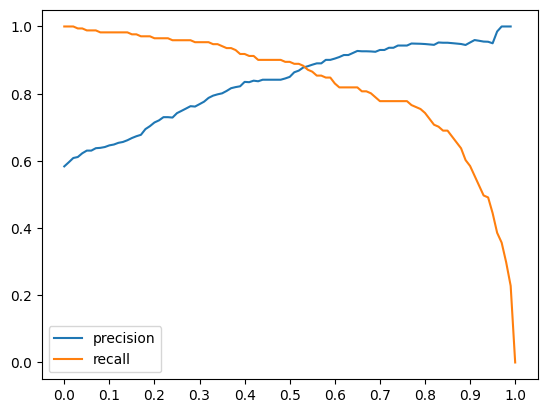

In [109]:
plt.plot(df_scores.threshold, df_scores['p'], label='precision')
plt.plot(df_scores.threshold, df_scores['r'], label='recall')
plt.xticks(np.arange(0, 1.01, 0.1))
plt.legend()

# Question 4: F1 score

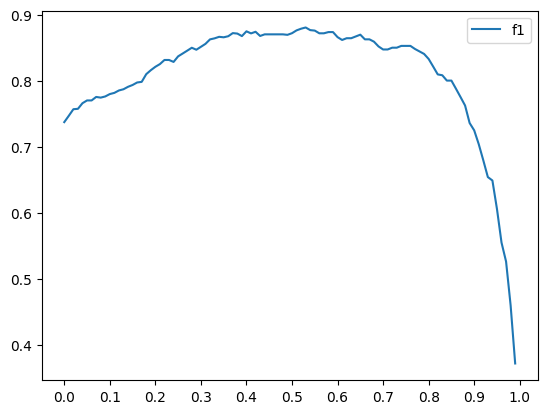

In [110]:
plt.plot(df_scores.threshold, df_scores['f1'], label='f1')
plt.xticks(np.arange(0, 1.01, 0.1))
plt.legend()

# Question 5: 5-Fold CV

In [113]:
from tqdm.auto import tqdm
from sklearn.model_selection import KFold

In [118]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values
    del df_train['converted']
    del df_val['converted']

    df_train[numerical] = scaler.fit_transform(df_train[numerical])
    df_val[numerical] = scaler.transform(df_val[numerical])

    dv = DictVectorizer(sparse=False)
    train_dict = df_train[categorical + numerical].to_dict(orient='records')
    x_train = dv.fit_transform(train_dict)
    val_dict = df_val[categorical + numerical].to_dict(orient='records')
    x_val = dv.transform(val_dict)

    model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
    model.fit(x_train, y_train)
    y_pred = model.predict_proba(x_val)[:, 1]

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.921 +- 0.010


# Question 6: Hyperparameter Tuning

In [119]:
for c in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values
        del df_train['converted']
        del df_val['converted']

        df_train[numerical] = scaler.fit_transform(df_train[numerical])
        df_val[numerical] = scaler.transform(df_val[numerical])

        dv = DictVectorizer(sparse=False)
        train_dict = df_train[categorical + numerical].to_dict(orient='records')
        x_train = dv.fit_transform(train_dict)
        val_dict = df_val[categorical + numerical].to_dict(orient='records')
        x_val = dv.transform(val_dict)

        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
        model.fit(x_train, y_train)
        y_pred = model.predict_proba(x_val)[:, 1]

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

  0%|          | 0/3 [00:00<?, ?it/s]

0.903 +- 0.013
0.905 +- 0.013
0.921 +- 0.010
